In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.utils.common_funcs import  set_time_grid, cont_integral
from src.spec_dens.spec_dens import SpecDensGapless
import src.utils.common_funcs as cf
from src.kernel_params.kernel_params import KernelParams
from src.kernel_matrix.kernel_matrix import KernelMatrix
from src.discr_error.discr_error import DiscrError
from src.decomp_kernel.decomp_kernel import DecompKernel

Project path successfully added.


In [2]:
Lambda = 5
N_max = 100 #number of time steps
beta = 2 #inverse temperature
sharpness = 10 #sharpness is nu which is MULTIPLIED with (w-Lambda) in the exponent
delta_t = 0.1

# Define the spectral density
spec_dens = SpecDensGapless(Lambda = Lambda, sharpness = sharpness)

params = KernelParams(spec_dens = spec_dens, n = 4200, m = 1000, N_max = 100, delta_t = 0.1, h = 0.005011872336272, beta = beta)



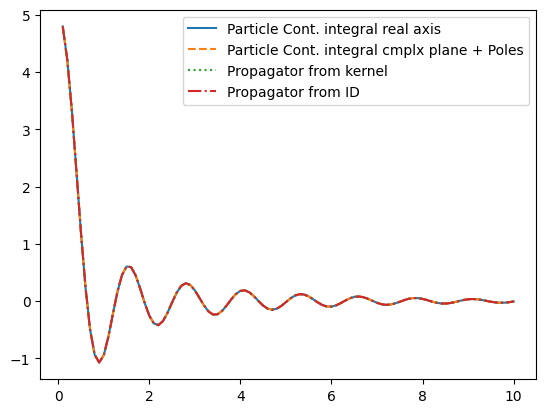

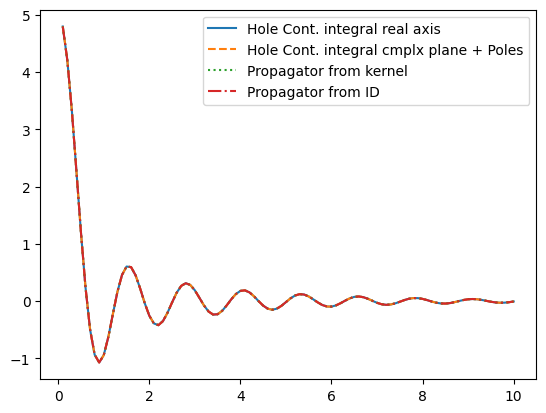

In [7]:
#create the time grid
time_grid = set_time_grid(N_max, delta_t)

#compute poles and residues for given spectral density
poles, residues = spec_dens.poles_residues()

#create kernel matrix which allows for the computation of the discrete propagator
kernel = DiscrError(**params.params, additional_poles=poles, additional_residues=residues)

#decompose the kernel using ID. Specify include_additional_poles = True to include the additional poles in the kernel that is decomposed
decomp = DecompKernel(kernel, include_additional_poles=True)
#reconstruct the propagator from the decomposed ID-kernel
propag_ID_reconstr = decomp.reconstruct_propagator_ID()

propag_kernel = kernel.discrete_integral(include_additional_poles=True)

#compute the continuous integral along REAL AXIS for only POSITIVE frequencies
cont_integral_particle = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens=spec_dens ,phi = 0.) #particle
cont_integral_hole = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens,phi = 0.) #hole

#compute the continuous integral along COMPLEX AXIS for only POSITIVE frequencies
cont_integral_particle_cmplx = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens = spec_dens)#particle
cont_integral_hole_cmplx = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens)#hole

#get poles and residues of the spectral density
poles, residues = spec_dens.poles_residues()
kernel_particles = 2.j * np.pi * residues * cf.dynamic_distr_particle(time_grid[:, np.newaxis], poles, beta) 
#hole component (negative sign in beta for hole distribution)
kernel_holes = 2.j * np.pi * residues * cf.dynamic_distr_particle(time_grid[:, np.newaxis], poles, -beta) 

#sum over the poles to determine the contribution to the propagator
G_poles_particle = np.sum(kernel_particles, axis = 1)
G_poles_hole = np.sum(kernel_holes, axis = 1)

#plot
plt.plot(time_grid, np.real(cont_integral_particle) , label= "Particle Cont. integral real axis")
plt.plot(time_grid, np.real(G_poles_particle + cont_integral_particle_cmplx), label = "Particle Cont. integral cmplx plane + Poles", linestyle = "--")
plt.plot(time_grid, np.real(propag_kernel)[:len(propag_kernel)//2], label = "Propagator from kernel", linestyle = "dotted")
plt.plot(time_grid, np.real(propag_ID_reconstr)[:len(propag_kernel)//2], label = "Propagator from ID", linestyle = "dashdot")
plt.legend()
plt.show()

plt.plot(time_grid, np.real(cont_integral_hole) , label= "Hole Cont. integral real axis")
plt.plot(time_grid, np.real(G_poles_hole + cont_integral_hole_cmplx), label = "Hole Cont. integral cmplx plane + Poles", linestyle = "--")
plt.plot(time_grid, np.real(propag_kernel)[len(propag_kernel)//2:], label = "Propagator from kernel", linestyle = "dotted")
plt.plot(time_grid, np.real(propag_ID_reconstr)[len(propag_kernel)//2:], label = "Propagator from ID", linestyle = "dashdot")
plt.legend()
plt.show()


